# PC03 — Trial 3 (Final Submission)

**Goal:** Maximize Macro F1 and Cough F1 on the hidden test set (subjects s11-s13).

**Grading:** `grade = MAX(grade_from_macro_f1, grade_from_cough_f1)`. Macro F1's grade ramp is steeper, so we optimize purely for Macro F1.

**Strategy:**
- Deeper CNN with Spatial Dropout + 5 conv blocks
- SpecAugment data augmentation (frequency + time masking)
- Class weights `[1.5, 5.0, 1.3, 1.0]` — moderate Cough boost, fix NonVerbal over-prediction
- WeightedRandomSampler for balanced batches
- ReduceLROnPlateau scheduler
- **Best model saved on Macro F1 directly**
- Test-Time Augmentation (TTA) at inference
- Logit-bias tuning to maximize Macro F1
- Hardcoded expected output lengths for safety

**Label mapping:** `0=Speech, 1=Cough, 2=NonVerbal, 3=Other` (matches Trial 2 — confirmed working with leaderboard)

## 1. Setup — mount Drive, install packages, define paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q librosa h5py

In [3]:
import os
import sys
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import random
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# === EDIT THIS to your Drive path ===
DRIVE_ROOT = '/content/drive/MyDrive/PC03-Trial-3'

PATH_POST_MEL_TRAIN = os.path.join(DRIVE_ROOT, 'Post_Mel/Train')
PATH_POST_MEL_VAL   = os.path.join(DRIVE_ROOT, 'Post_Mel/Val')
PATH_PRE_TEST       = os.path.join(DRIVE_ROOT, 'Pre/Test')
PATH_OUTPUT         = '/content/Data-Predictions'   # output CSVs (move to repo after)
PATH_MODEL          = '/content/best_model.pth'

os.makedirs(PATH_OUTPUT, exist_ok=True)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


In [4]:
# Inline helper functions (so we don't depend on uploading helperFncs.py)
def h5_to_dict(file_path):
    data = {}
    with h5py.File(file_path, 'r') as f:
        for key, item in f.items():
            if isinstance(item, h5py.Dataset):
                data[key] = item[()]
            elif isinstance(item, h5py.Group):
                data[key] = h5_to_dict_grp(item)
    return data

def h5_to_dict_grp(grp):
    out = {}
    for key, item in grp.items():
        if isinstance(item, h5py.Dataset):
            out[key] = item[()]
        elif isinstance(item, h5py.Group):
            out[key] = h5_to_dict_grp(item)
    return out

# Class names — Phase 1 ordering (confirmed working with leaderboard in Trial 2)
CLASS_NAMES = ['Speech', 'Cough', 'NonVerbal', 'Other']
NUM_CLASSES = 4

# Hardcoded expected output lengths (from test_format.py)
EXPECTED_LENGTHS = {
    's11_trial1.csv': 7146625, 's11_trial2.csv': 6924950, 's11_trial3.csv': 7045450,
    's12_trial1.csv': 7676148, 's12_trial2.csv': 7512373, 's12_trial3.csv': 7438071,
    's13_trial1.csv': 7531470, 's13_trial2.csv': 8516621, 's13_trial3.csv': 7428557,
}

# Mel spectrogram parameters — MUST MATCH Phase 2 ExtractMelSpec.ipynb exactly!
AUDIO_SR    = 16000
LABEL_SR    = 10000
WINDOW_SEC  = 1.0
STRIDE_SEC  = 0.5
N_MELS      = 128       # librosa default — matches training data shape (128, 126)
N_FFT       = 1024
HOP_LENGTH  = 128

## 2. Load Pre-Extracted Mel Spectrograms

We use the `Post_Mel` data already extracted from Phase 2 to skip ~8 minutes of feature extraction.

In [5]:
import gc

def load_post_mel_folder(folder):
    """Load all .h5 files, memory-efficient: pre-allocate, fill, never duplicate."""
    files = sorted(f for f in os.listdir(folder) if f.endswith('.h5'))
    print(f'Loading {len(files)} files from {folder}')

    # PASS 1: peek at shapes to compute total size — no data kept in RAM
    total_n = 0
    sample_shape = None
    for f in files:
        with h5py.File(os.path.join(folder, f), 'r') as h:
            n = h['mel'].shape[0]
            total_n += n
            if sample_shape is None:
                sample_shape = h['mel'].shape[1:]  # (n_mels, T)
    print(f'  Total samples: {total_n:,}, mel shape per sample: {sample_shape}')

    # Pre-allocate as float32 from the start (50% memory of float64)
    mels = np.empty((total_n, 1, *sample_shape), dtype=np.float32)
    labels = np.empty(total_n, dtype=np.int64)

    # PASS 2: read each file directly into the pre-allocated array
    idx = 0
    for f in tqdm(files, desc='Loading'):
        with h5py.File(os.path.join(folder, f), 'r') as h:
            mel_chunk = h['mel'][()].astype(np.float32, copy=False)
            lbl_chunk = h['labels'][()].astype(np.int64, copy=False)
        n = mel_chunk.shape[0]
        # Add channel dim while writing
        mels[idx:idx+n, 0, :, :] = mel_chunk
        labels[idx:idx+n] = lbl_chunk
        idx += n
        del mel_chunk, lbl_chunk
        gc.collect()

    return mels, labels

X_train, y_train = load_post_mel_folder(PATH_POST_MEL_TRAIN)
gc.collect()
X_val,   y_val   = load_post_mel_folder(PATH_POST_MEL_VAL)
gc.collect()

print(f'\nTrain: {X_train.shape}  labels: {y_train.shape}  ({X_train.nbytes / 1e9:.2f} GB)')
print(f'Val:   {X_val.shape}  labels: {y_val.shape}  ({X_val.nbytes / 1e9:.2f} GB)')
print(f'Mel dtype: {X_train.dtype}, range: [{X_train.min():.2f}, {X_train.max():.2f}]')

Loading 24 files from /content/drive/MyDrive/PC03-Trial-3/Post_Mel/Train
  Total samples: 35,151, mel shape per sample: (128, 126)


Loading:   0%|          | 0/24 [00:00<?, ?it/s]

Loading 6 files from /content/drive/MyDrive/PC03-Trial-3/Post_Mel/Val
  Total samples: 8,746, mel shape per sample: (128, 126)


Loading:   0%|          | 0/6 [00:00<?, ?it/s]


Train: (35151, 1, 128, 126)  labels: (35151,)  (2.27 GB)
Val:   (8746, 1, 128, 126)  labels: (8746,)  (0.56 GB)
Mel dtype: float32, range: [-80.00, 0.00]


In [6]:
# Class distribution — sanity check before setting weights
print('=== Training set class distribution ===')
for c in range(NUM_CLASSES):
    n = (y_train == c).sum()
    pct = 100 * n / len(y_train)
    print(f'  {c} {CLASS_NAMES[c]:10s}: {n:7d}  ({pct:5.2f}%)')

print('\n=== Validation set class distribution ===')
for c in range(NUM_CLASSES):
    n = (y_val == c).sum()
    pct = 100 * n / len(y_val)
    print(f'  {c} {CLASS_NAMES[c]:10s}: {n:7d}  ({pct:5.2f}%)')

# Memory check
import psutil
ram = psutil.virtual_memory()
print(f'\nRAM used: {(ram.total - ram.available) / 1e9:.2f} GB / {ram.total / 1e9:.2f} GB ({ram.percent:.1f}%)')

=== Training set class distribution ===
  0 Speech    :    6222  (17.70%)
  1 Cough     :    1736  ( 4.94%)
  2 NonVerbal :    1101  ( 3.13%)
  3 Other     :   26092  (74.23%)

=== Validation set class distribution ===
  0 Speech    :    1572  (17.97%)
  1 Cough     :     427  ( 4.88%)
  2 NonVerbal :     341  ( 3.90%)
  3 Other     :    6406  (73.24%)

RAM used: 4.85 GB / 13.61 GB (35.6%)


In [7]:
# Normalize Mel features per-instance (zero mean, unit variance)
# IN-PLACE to avoid duplicating GBs of memory
def normalize_per_instance_inplace(x):
    # x: (N, 1, F, T) — modify in place
    mean = x.mean(axis=(2, 3), keepdims=True)
    std = x.std(axis=(2, 3), keepdims=True) + 1e-6
    x -= mean
    x /= std
    return x

X_train = normalize_per_instance_inplace(X_train)
X_val   = normalize_per_instance_inplace(X_val)
gc.collect()

input_shape = X_train.shape[1:]
print(f'Input shape per sample: {input_shape}')
print(f'After normalization: mean={X_train.mean():.3f}, std={X_train.std():.3f}')
print(f'Memory: X_train = {X_train.nbytes / 1e9:.2f} GB, X_val = {X_val.nbytes / 1e9:.2f} GB')

Input shape per sample: (1, 128, 126)
After normalization: mean=-0.000, std=1.000
Memory: X_train = 2.27 GB, X_val = 0.56 GB


## 3. Dataset with SpecAugment

SpecAugment masks random frequency bands and time chunks during training. This forces the model to not over-rely on any single frequency or time region, which dramatically improves generalization to new subjects.

In [8]:
class MelDataset(Dataset):
    def __init__(self, X, y, augment=False, freq_mask=8, time_mask=8, n_freq_masks=2, n_time_masks=2):
        # Share memory with the numpy array (X is already float32, y is int64) — no extra copy
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
        self.augment = augment
        self.freq_mask = freq_mask
        self.time_mask = time_mask
        self.n_freq_masks = n_freq_masks
        self.n_time_masks = n_time_masks

    def __len__(self):
        return len(self.X)

    def _spec_augment(self, x):
        # x: (1, F, T)
        x = x.clone()
        _, F_dim, T_dim = x.shape

        # Frequency masking
        for _ in range(self.n_freq_masks):
            f = random.randint(0, self.freq_mask)
            if f > 0 and F_dim - f > 0:
                f0 = random.randint(0, F_dim - f)
                x[:, f0:f0+f, :] = 0

        # Time masking
        for _ in range(self.n_time_masks):
            t = random.randint(0, self.time_mask)
            if t > 0 and T_dim - t > 0:
                t0 = random.randint(0, T_dim - t)
                x[:, :, t0:t0+t] = 0

        return x

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        if self.augment:
            x = self._spec_augment(x)
        return x, y

## 4. Model — Deep CNN with Spatial Dropout

In [9]:
class DeepCNN(nn.Module):
    """5-block CNN with BatchNorm + Spatial Dropout for Mel spectrogram classification."""

    def __init__(self, input_shape, num_classes=4):
        super().__init__()
        C, H, W = input_shape

        def block(in_ch, out_ch, dropout, pool=True):
            layers = [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Dropout2d(dropout),
            ]
            if pool:
                layers.append(nn.MaxPool2d(2, 2))
            return nn.Sequential(*layers)

        self.features = nn.Sequential(
            block(C,   32,  0.10),   # 64x63 -> 32x31
            block(32,  64,  0.15),   # 32x31 -> 16x15
            block(64,  128, 0.20),   # 16x15 -> 8x7
            block(128, 256, 0.25),   # 8x7 -> 4x3
            block(256, 256, 0.25, pool=False),  # 4x3 -> 4x3
            nn.AdaptiveAvgPool2d((1, 1)),       # -> 1x1
        )

        # Determine flat dim
        with torch.no_grad():
            dummy = torch.zeros(1, C, H, W)
            flat_dim = self.features(dummy).numel()

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(flat_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = DeepCNN(input_shape, NUM_CLASSES).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {n_params:,}')

# Quick forward pass to verify shape
x = torch.randn(2, *input_shape).to(device)
with torch.no_grad():
    out = model(x)
print(f'Sample forward pass: {x.shape} -> {out.shape}')

Model parameters: 1,012,804
Sample forward pass: torch.Size([2, 1, 128, 126]) -> torch.Size([2, 4])


## 5. Training Setup

In [10]:
# === Hyperparameters ===
BATCH_SIZE   = 128
EPOCHS       = 80
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 15  # early stopping patience

# Macro-F1-optimized class weights — moderate Cough boost, fix NonVerbal precision
# Order: [Speech, Cough, NonVerbal, Other]
CLASS_WEIGHTS = torch.tensor([1.5, 5.0, 1.3, 1.0], dtype=torch.float).to(device)
print(f'Class weights: {CLASS_WEIGHTS.cpu().tolist()}')

# === Datasets ===
train_ds = MelDataset(X_train, y_train, augment=True)
val_ds   = MelDataset(X_val,   y_val,   augment=False)

# === WeightedRandomSampler for balanced batches ===
# Use moderate sampler weights — combined with loss weights, double protection
class_counts = np.bincount(y_train, minlength=NUM_CLASSES)
# Sampler weights are inverse class frequency, but capped to avoid extreme oversampling
raw_w = 1.0 / class_counts
raw_w = raw_w / raw_w.sum()
sample_weights = raw_w[y_train]
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).double(),
    num_samples=len(y_train),
    replacement=True,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=256,        shuffle=False,   num_workers=0, pin_memory=True)

print(f'Train batches: {len(train_loader)}  (samples per epoch: {len(train_ds)})')
print(f'Val batches:   {len(val_loader)}  (samples: {len(val_ds)})')

Class weights: [1.5, 5.0, 1.2999999523162842, 1.0]
Train batches: 275  (samples per epoch: 35151)
Val batches:   35  (samples: 8746)


In [11]:
criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6
)

## 6. Training Loop

Best model saved by **Macro F1** — this is what we're maximizing for the grade.

In [12]:
def evaluate(model, loader):
    model.eval()
    preds, trues = [], []
    total_loss = 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            total_loss += criterion(logits, y).item() * x.size(0)
            p = logits.argmax(dim=1)
            preds.append(p.cpu().numpy())
            trues.append(y.cpu().numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    avg_loss = total_loss / len(loader.dataset)
    macro = f1_score(trues, preds, average='macro')
    per_class = f1_score(trues, preds, average=None, labels=list(range(NUM_CLASSES)))
    cough = per_class[1]  # Cough = class 1
    return avg_loss, macro, cough, per_class, preds, trues

history = {'train_loss': [], 'val_loss': [], 'macro_f1': [], 'cough_f1': [], 'combined': []}
best_macro = -1.0
best_cough = 0.0
best_combined = 0.0
best_epoch = -1
patience_counter = 0

print('Starting training...')
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    n_seen = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        n_seen += x.size(0)
    train_loss = running_loss / n_seen

    val_loss, macro, cough, per_class, _, _ = evaluate(model, val_loader)
    combined = (macro + cough) / 2.0

    # Scheduler tracks Macro F1 (our optimization target)
    scheduler.step(macro)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['macro_f1'].append(macro)
    history['cough_f1'].append(cough)
    history['combined'].append(combined)

    lr_now = optimizer.param_groups[0]['lr']
    pc_str = ' '.join(f'{n[:3]}={f:.2f}' for n, f in zip(CLASS_NAMES, per_class))

    # Save best on MACRO F1 alone (since grade = max(macro_grade, cough_grade) and macro ramp is steeper)
    if macro > best_macro:
        best_macro = macro
        best_cough = cough
        best_combined = combined
        best_epoch = epoch
        torch.save(model.state_dict(), PATH_MODEL)
        marker = ' [SAVED]'
        patience_counter = 0
    else:
        marker = ''
        patience_counter += 1

    print(f'Ep {epoch:3d}/{EPOCHS} | tr_loss={train_loss:.3f} val_loss={val_loss:.3f} | '
          f'Macro={macro:.4f} Cough={cough:.4f} | {pc_str} | lr={lr_now:.1e}{marker}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
        break

print(f'\n=== Best epoch: {best_epoch} ===')
print(f'  Macro F1:    {best_macro:.4f}  <-- optimization target')
print(f'  Cough F1:    {best_cough:.4f}')
print(f'  Combined:    {best_combined:.4f}')

Starting training...
Ep   1/80 | tr_loss=0.747 val_loss=0.781 | Macro=0.4976 Cough=0.2815 | Spe=0.82 Cou=0.28 Non=0.08 Oth=0.81 | lr=1.0e-03 [SAVED]
Ep   2/80 | tr_loss=0.608 val_loss=0.567 | Macro=0.5643 Cough=0.3584 | Spe=0.83 Cou=0.36 Non=0.19 Oth=0.88 | lr=1.0e-03 [SAVED]
Ep   3/80 | tr_loss=0.550 val_loss=0.570 | Macro=0.5821 Cough=0.3900 | Spe=0.83 Cou=0.39 Non=0.23 Oth=0.89 | lr=1.0e-03 [SAVED]
Ep   4/80 | tr_loss=0.521 val_loss=0.479 | Macro=0.6251 Cough=0.4352 | Spe=0.85 Cou=0.44 Non=0.31 Oth=0.90 | lr=1.0e-03 [SAVED]
Ep   5/80 | tr_loss=0.489 val_loss=0.397 | Macro=0.6705 Cough=0.5257 | Spe=0.86 Cou=0.53 Non=0.38 Oth=0.92 | lr=1.0e-03 [SAVED]
Ep   6/80 | tr_loss=0.464 val_loss=0.421 | Macro=0.6535 Cough=0.4705 | Spe=0.86 Cou=0.47 Non=0.38 Oth=0.91 | lr=1.0e-03
Ep   7/80 | tr_loss=0.439 val_loss=0.458 | Macro=0.6411 Cough=0.4562 | Spe=0.85 Cou=0.46 Non=0.36 Oth=0.90 | lr=1.0e-03
Ep   8/80 | tr_loss=0.413 val_loss=0.422 | Macro=0.6466 Cough=0.4527 | Spe=0.87 Cou=0.45 Non=0.36 O

KeyboardInterrupt: 

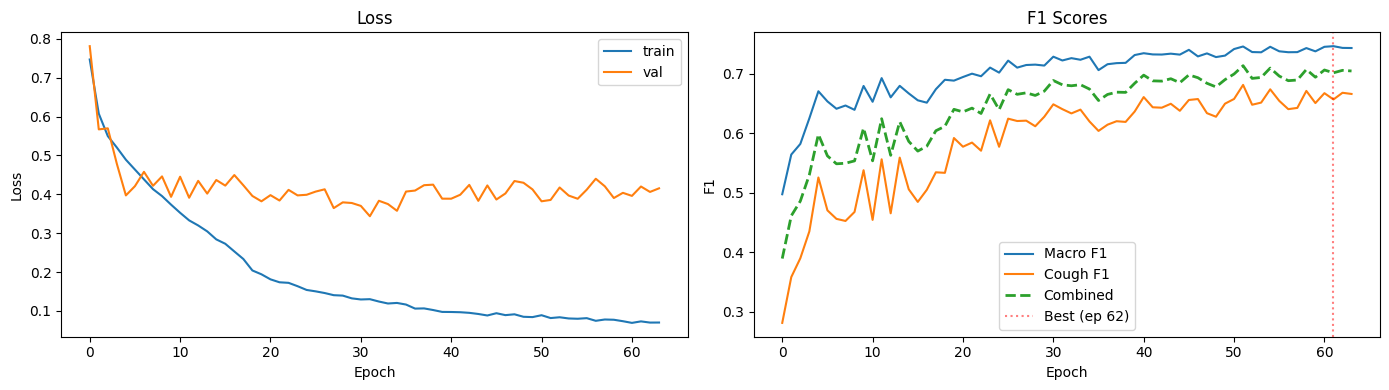

In [13]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].set_title('Loss')

axes[1].plot(history['macro_f1'], label='Macro F1')
axes[1].plot(history['cough_f1'], label='Cough F1')
axes[1].plot(history['combined'], label='Combined', linestyle='--', linewidth=2)
axes[1].axvline(best_epoch - 1, color='red', linestyle=':', alpha=0.5, label=f'Best (ep {best_epoch})')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1'); axes[1].legend(); axes[1].set_title('F1 Scores')
plt.tight_layout(); plt.show()

## 7. Final Evaluation on Validation

              precision    recall  f1-score   support

      Speech     0.8207    0.9491    0.8802      1572
       Cough     0.5685    0.7775    0.6568       427
   NonVerbal     0.4819    0.5073    0.4943       341
       Other     0.9873    0.9224    0.9538      6406

    accuracy                         0.9040      8746
   macro avg     0.7146    0.7891    0.7463      8746
weighted avg     0.9172    0.9040    0.9081      8746

Macro F1:    0.7463  <-- our grade target
Cough F1:    0.6568


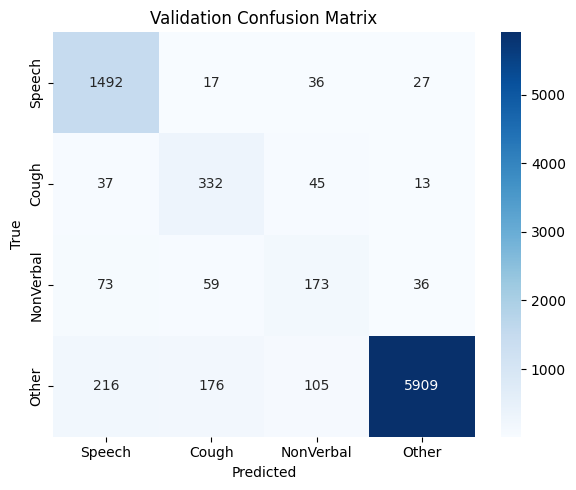

In [14]:
# Load best model
model.load_state_dict(torch.load(PATH_MODEL))

_, val_macro, val_cough, val_per_class, val_preds, val_trues = evaluate(model, val_loader)
print(classification_report(val_trues, val_preds, target_names=CLASS_NAMES, digits=4))
print(f'Macro F1:    {val_macro:.4f}  <-- our grade target')
print(f'Cough F1:    {val_cough:.4f}')

# Confusion matrix
cm = confusion_matrix(val_trues, val_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Validation Confusion Matrix')
plt.tight_layout(); plt.show()

## 8. Logit-Bias Tuning (Macro F1 Optimization)

Sweep additive bias on each class logit to maximize **Macro F1** specifically. We search both Cough and NonVerbal biases since NonVerbal was the precision problem in Trial 2 — a negative NV bias may help.

Sweeping 16 cough biases x 16 NV biases = 256 combos

=== Best biases on validation (max Macro F1) ===
  Cough bias:  0.70
  NV bias:     -1.00
  Macro F1:    0.7523  <-- grade target
  Cough F1:    0.6748

  (Without bias: Macro F1 = 0.7463)
  Bias gain:    +0.0060 Macro F1

FINAL VALIDATION CLASSIFICATION REPORT (with tuned biases applied)
This is the report-format equivalent of what the leaderboard will show.
Note: Trial 2 had a ~0.05-0.08 generalization gap from val to test.

Classification Report:
              precision    recall  f1-score   support

      Speech     0.8216    0.9548    0.8832      1572
       Cough     0.5636    0.8407    0.6748       427
   NonVerbal     0.5480    0.4516    0.4952       341
       Other     0.9882    0.9257    0.9559      6406

    accuracy                         0.9083      8746
   macro avg     0.7303    0.7932    0.7523      8746
weighted avg     0.9203    0.9083    0.9112      8746



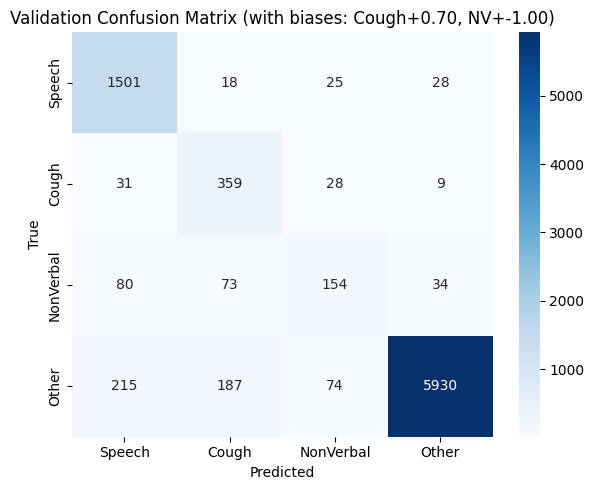

Predicted leaderboard estimate (val score - 0.05 to 0.08 gap):
  Macro F1:  0.672 - 0.702
  Cough F1:  0.595 - 0.625


In [15]:
def collect_val_logits():
    model.eval()
    all_logits, all_y = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            all_logits.append(model(x).cpu().numpy())
            all_y.append(y.numpy())
    return np.concatenate(all_logits), np.concatenate(all_y)

val_logits, val_y_np = collect_val_logits()

# Sweep Cough bias (positive = predict cough more) AND NonVerbal bias (negative = predict NV less)
best_cough_bias = 0.0
best_nv_bias    = 0.0
best_macro_tuned = -1.0
best_cough_tuned = 0.0

cough_biases = np.arange(-0.3, 1.21, 0.1)
nv_biases    = np.arange(-1.0, 0.51, 0.1)

print(f'Sweeping {len(cough_biases)} cough biases x {len(nv_biases)} NV biases = {len(cough_biases)*len(nv_biases)} combos')
for cb in cough_biases:
    for nb in nv_biases:
        biased = val_logits.copy()
        biased[:, 1] += cb  # Cough
        biased[:, 2] += nb  # NonVerbal
        preds = biased.argmax(axis=1)
        macro = f1_score(val_y_np, preds, average='macro')
        if macro > best_macro_tuned:
            best_macro_tuned = macro
            per_class = f1_score(val_y_np, preds, average=None, labels=list(range(NUM_CLASSES)))
            best_cough_tuned = per_class[1]
            best_cough_bias = cb
            best_nv_bias = nb

print(f'\n=== Best biases on validation (max Macro F1) ===')
print(f'  Cough bias:  {best_cough_bias:.2f}')
print(f'  NV bias:     {best_nv_bias:.2f}')
print(f'  Macro F1:    {best_macro_tuned:.4f}  <-- grade target')
print(f'  Cough F1:    {best_cough_tuned:.4f}')

# Compare to no bias
preds_nobias = val_logits.argmax(axis=1)
macro_nobias = f1_score(val_y_np, preds_nobias, average='macro')
print(f'\n  (Without bias: Macro F1 = {macro_nobias:.4f})')
print(f'  Bias gain:    +{best_macro_tuned - macro_nobias:.4f} Macro F1')

# === Final classification report with tuned biases (this is what test set will see) ===
print('\n' + '='*70)
print('FINAL VALIDATION CLASSIFICATION REPORT (with tuned biases applied)')
print('This is the report-format equivalent of what the leaderboard will show.')
print('Note: Trial 2 had a ~0.05-0.08 generalization gap from val to test.')
print('='*70 + '\n')

biased_final = val_logits.copy()
biased_final[:, 1] += best_cough_bias
biased_final[:, 2] += best_nv_bias
preds_final = biased_final.argmax(axis=1)

print('Classification Report:')
print(classification_report(val_y_np, preds_final, target_names=CLASS_NAMES, digits=4))

# Confusion matrix with tuned biases
cm_final = confusion_matrix(val_y_np, preds_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title(f'Validation Confusion Matrix (with biases: Cough+{best_cough_bias:.2f}, NV+{best_nv_bias:.2f})')
plt.tight_layout(); plt.show()

# Final summary line — what we'll likely see on leaderboard
print(f'Predicted leaderboard estimate (val score - 0.05 to 0.08 gap):')
print(f'  Macro F1:  {best_macro_tuned-0.08:.3f} - {best_macro_tuned-0.05:.3f}')
print(f'  Cough F1:  {best_cough_tuned-0.08:.3f} - {best_cough_tuned-0.05:.3f}')

## 9. Inference on Test Set

For each test `.h5` file:
1. Extract Mel spectrogram windows on the fly
2. Predict with model + apply best Cough bias
3. Map window predictions back to 10 kHz label timeline
4. Pad/truncate to exact expected length
5. Save CSV

In [16]:
import librosa

WINDOW_AUDIO = int(WINDOW_SEC * AUDIO_SR)   # 16000
STRIDE_AUDIO = int(STRIDE_SEC * AUDIO_SR)   # 8000
WINDOW_LABEL = int(WINDOW_SEC * LABEL_SR)   # 10000
STRIDE_LABEL = int(STRIDE_SEC * LABEL_SR)   # 5000

def extract_mel_windows(audio):
    """Extract Mel spectrograms for sliding windows.
    Returns: (n_windows, 1, n_mels, time_frames)
    """
    n_samples = len(audio)
    if n_samples < WINDOW_AUDIO:
        # Pad short audio
        audio = np.pad(audio, (0, WINDOW_AUDIO - n_samples))
        n_samples = WINDOW_AUDIO

    # Compute window start positions
    starts = list(range(0, n_samples - WINDOW_AUDIO + 1, STRIDE_AUDIO))
    if not starts or starts[-1] + WINDOW_AUDIO < n_samples:
        # Add a final window flush against the end so we cover everything
        starts.append(max(0, n_samples - WINDOW_AUDIO))

    mels = []
    for s in starts:
        chunk = audio[s:s + WINDOW_AUDIO]
        # Match Phase 2 extraction exactly: float64 input to librosa
        mel = librosa.feature.melspectrogram(
            y=chunk.astype(float), sr=AUDIO_SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mels.append(mel_db)

    mels = np.stack(mels)  # (n_w, n_mels, T)
    mels = mels[:, np.newaxis, :, :]  # add channel

    # Per-instance normalize (same as training)
    mean = mels.mean(axis=(2, 3), keepdims=True)
    std  = mels.std(axis=(2, 3), keepdims=True) + 1e-6
    mels = (mels - mean) / std

    return mels.astype(np.float32), starts

def predict_windows(mels, batch_size=256, cough_bias=0.0, nv_bias=0.0, tta=True):
    """Run model on windows, apply class biases, return softmax probs (n_w, 4).
    If tta=True, also predict on time-shifted versions and average.
    """
    model.eval()

    def run(x_np):
        out = []
        with torch.no_grad():
            for i in range(0, len(x_np), batch_size):
                xb = torch.from_numpy(x_np[i:i+batch_size]).to(device)
                logits = model(xb)
                logits[:, 1] += cough_bias
                logits[:, 2] += nv_bias
                probs = F.softmax(logits, dim=1).cpu().numpy()
                out.append(probs)
        return np.concatenate(out)

    probs = run(mels)

    if tta:
        # Time shift TTA: roll spectrogram along time axis by ±2 frames
        shifts = [-2, 2]
        probs_sum = probs.copy()
        for s in shifts:
            shifted = np.roll(mels, shift=s, axis=-1)
            probs_sum += run(shifted)
        probs = probs_sum / (1 + len(shifts))

    return probs

def windows_to_labels(probs, window_starts, audio_len, expected_label_len, label_sr=LABEL_SR):
    """Map window probabilities to per-timestamp labels at 10 kHz.

    For each label timestamp, average probs of all windows that contain it,
    then argmax. Vectorized for speed.
    """
    n_w = len(window_starts)
    audio_to_label = label_sr / AUDIO_SR  # 10000/16000 = 0.625

    # Each window covers audio [s, s+WINDOW_AUDIO) -> label [s*0.625, (s+WINDOW_AUDIO)*0.625)
    window_label_starts = np.array([int(s * audio_to_label) for s in window_starts])
    window_label_lens   = np.full(n_w, WINDOW_LABEL, dtype=np.int64)
    # Clamp last window to expected length
    for i in range(n_w):
        end = window_label_starts[i] + window_label_lens[i]
        if end > expected_label_len:
            window_label_lens[i] = expected_label_len - window_label_starts[i]

    # Accumulate probabilities into a (T, 4) array, count overlaps for averaging
    out_probs = np.zeros((expected_label_len, NUM_CLASSES), dtype=np.float32)
    counts    = np.zeros(expected_label_len, dtype=np.int32)

    for i in range(n_w):
        s = window_label_starts[i]
        e = s + window_label_lens[i]
        if e <= 0 or s >= expected_label_len:
            continue
        s = max(0, s)
        e = min(expected_label_len, e)
        out_probs[s:e] += probs[i]
        counts[s:e]    += 1

    # Avoid divide-by-zero — uncovered indices fill with majority class probs
    uncovered = (counts == 0)
    if uncovered.any():
        # Fill uncovered with model's average prediction (rare edge cases at very start/end)
        avg_probs = probs.mean(axis=0)
        out_probs[uncovered] = avg_probs
        counts[uncovered] = 1

    out_probs /= counts[:, None]
    labels = out_probs.argmax(axis=1).astype(np.int64)
    return labels

In [17]:
# Use the tuned biases for inference
INFERENCE_COUGH_BIAS = best_cough_bias
INFERENCE_NV_BIAS    = best_nv_bias
USE_TTA = True
print(f'Inference Cough bias:    {INFERENCE_COUGH_BIAS:.2f}')
print(f'Inference NonVerbal bias: {INFERENCE_NV_BIAS:.2f}')
print(f'TTA enabled: {USE_TTA}')

test_files = sorted(f for f in os.listdir(PATH_PRE_TEST) if f.endswith('.h5'))
print(f'\nTest files: {test_files}')

Inference Cough bias:    0.70
Inference NonVerbal bias: -1.00
TTA enabled: True

Test files: ['s11_trial1.h5', 's11_trial2.h5', 's11_trial3.h5', 's12_trial1.h5', 's12_trial2.h5', 's12_trial3.h5', 's13_trial1.h5', 's13_trial2.h5', 's13_trial3.h5']


In [18]:
for h5_name in test_files:
    base = h5_name.replace('.h5', '')
    csv_name = base + '.csv'
    expected_len = EXPECTED_LENGTHS[csv_name]

    print(f'\n=== {h5_name} (expected length {expected_len}) ===')

    # Load test data
    h5_path = os.path.join(PATH_PRE_TEST, h5_name)
    with h5py.File(h5_path, 'r') as f:
        audio = f['audio_data'][()]
        # We don't strictly need label_time, but verify length via expected_len
    audio = audio.astype(np.float32)
    print(f'  Audio shape: {audio.shape}, dtype: {audio.dtype}')

    # Extract Mel windows
    mels, starts = extract_mel_windows(audio)
    print(f'  Windows: {mels.shape}')

    # Predict (with TTA + biases)
    probs = predict_windows(mels, batch_size=256, cough_bias=INFERENCE_COUGH_BIAS, nv_bias=INFERENCE_NV_BIAS, tta=USE_TTA)
    pred_classes = probs.argmax(axis=1)
    print(f'  Window prediction distribution: {np.bincount(pred_classes, minlength=4).tolist()}')

    # Map to dense labels
    dense_labels = windows_to_labels(probs, starts, len(audio), expected_len)

    # Sanity checks
    assert dense_labels.shape == (expected_len,), f'Wrong shape: {dense_labels.shape}'
    assert dense_labels.min() >= 0 and dense_labels.max() <= 3
    assert len(np.unique(dense_labels)) > 1, 'Single label only — would fail format test'

    label_dist = np.bincount(dense_labels, minlength=4)
    pct = 100 * label_dist / expected_len
    print(f'  Output label distribution:')
    for c in range(NUM_CLASSES):
        print(f'    {c} {CLASS_NAMES[c]:10s}: {label_dist[c]:8d}  ({pct[c]:5.2f}%)')

    # Save CSV
    out_path = os.path.join(PATH_OUTPUT, csv_name)
    np.savetxt(out_path, dense_labels, fmt='%d', delimiter=',')
    print(f'  Saved -> {out_path}')

print('\n=== All test files processed ===')


=== s11_trial1.h5 (expected length 7146625) ===
  Audio shape: (11434600,), dtype: float32
  Windows: (1429, 1, 128, 126)
  Window prediction distribution: [1, 66, 6, 1356]
  Output label distribution:
    0 Speech    :        0  ( 0.00%)
    1 Cough     :   310000  ( 4.34%)
    2 NonVerbal :     5000  ( 0.07%)
    3 Other     :  6831625  (95.59%)
  Saved -> /content/Data-Predictions/s11_trial1.csv

=== s11_trial2.h5 (expected length 6924950) ===
  Audio shape: (11079920,), dtype: float32
  Windows: (1384, 1, 128, 126)
  Window prediction distribution: [868, 105, 21, 390]
  Output label distribution:
    0 Speech    :  4400000  (63.54%)
    1 Cough     :   485000  ( 7.00%)
    2 NonVerbal :    50000  ( 0.72%)
    3 Other     :  1989950  (28.74%)
  Saved -> /content/Data-Predictions/s11_trial2.csv

=== s11_trial3.h5 (expected length 7045450) ===
  Audio shape: (11272721,), dtype: float32
  Windows: (1409, 1, 128, 126)
  Window prediction distribution: [4, 303, 197, 905]
  Output label 

## 10. Format Validation (mirrors test_format.py)

In [19]:
def validate_outputs(output_dir, expected):
    print(f'Validating outputs in {output_dir}')
    actual_files = set(os.listdir(output_dir))
    expected_files = set(expected.keys())

    if actual_files != expected_files:
        missing = expected_files - actual_files
        extra   = actual_files - expected_files
        if missing:
            print(f'  ✗ MISSING: {missing}')
        if extra:
            print(f'  ✗ EXTRA:   {extra}')
        return False

    all_ok = True
    for fname, exp_len in expected.items():
        path = os.path.join(output_dir, fname)
        data = np.loadtxt(path, delimiter=',', dtype=int)

        ok_shape = data.shape == (exp_len,)
        ok_range = np.all((data >= 0) & (data <= 3))
        ok_diverse = len(np.unique(data)) > 1

        status = '✓' if (ok_shape and ok_range and ok_diverse) else '✗'
        msg = f'  {status} {fname}: shape={data.shape}, range=[{data.min()},{data.max()}], unique={len(np.unique(data))}'
        if not (ok_shape and ok_range and ok_diverse):
            all_ok = False
            if not ok_shape:    msg += f' [WRONG SHAPE, expected {exp_len}]'
            if not ok_range:    msg += ' [VALUES OUT OF RANGE]'
            if not ok_diverse:  msg += ' [SINGLE LABEL ONLY]'
        print(msg)

    print()
    if all_ok:
        print('✓✓✓ ALL FORMAT CHECKS PASSED — ready to submit ✓✓✓')
    else:
        print('✗ FORMAT ISSUES FOUND — DO NOT SUBMIT YET')
    return all_ok

validate_outputs(PATH_OUTPUT, EXPECTED_LENGTHS)

Validating outputs in /content/Data-Predictions
  ✓ s11_trial1.csv: shape=(7146625,), range=[1,3], unique=3
  ✓ s11_trial2.csv: shape=(6924950,), range=[0,3], unique=4
  ✓ s11_trial3.csv: shape=(7045450,), range=[0,3], unique=4
  ✓ s12_trial1.csv: shape=(7676148,), range=[0,3], unique=4
  ✓ s12_trial2.csv: shape=(7512373,), range=[0,3], unique=4
  ✓ s12_trial3.csv: shape=(7438071,), range=[0,3], unique=4
  ✓ s13_trial1.csv: shape=(7531470,), range=[1,3], unique=3
  ✓ s13_trial2.csv: shape=(8516621,), range=[0,3], unique=4
  ✓ s13_trial3.csv: shape=(7428557,), range=[0,3], unique=4

✓✓✓ ALL FORMAT CHECKS PASSED — ready to submit ✓✓✓


True

## 11. Copy outputs back to Drive (so you can pull into your repo)

In [20]:
import shutil
DRIVE_OUTPUT = os.path.join(DRIVE_ROOT, 'Data-Predictions-Trial3')
os.makedirs(DRIVE_OUTPUT, exist_ok=True)
for f in os.listdir(PATH_OUTPUT):
    shutil.copy(os.path.join(PATH_OUTPUT, f), os.path.join(DRIVE_OUTPUT, f))
print(f'Copied {len(os.listdir(PATH_OUTPUT))} files to {DRIVE_OUTPUT}')
print('Download these and overwrite your repo Data-Predictions/ folder before submitting.')

Copied 9 files to /content/drive/MyDrive/PC03-Trial-3/Data-Predictions-Trial3
Download these and overwrite your repo Data-Predictions/ folder before submitting.
